# Unit 1 — Introduction

The practice questions of this unit (21CSC305P). Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Practice 1 — Devise a program to import, load and view dataset

Read the CSV file into a table, then look at its size, its column types and its first rows.

In [2]:
from weather import load

d = load()                                          # reads data/seattle_weather.csv
raw = d[["date", "precipitation", "temp_max", "temp_min", "wind", "weather"]]
print("rows, columns:", raw.shape)
print("period:", d.date.min().date(), "to", d.date.max().date(), "\n")
print(raw.dtypes, "\n")
print(raw.head(10).to_string(index=False))
print("\nWeather labels:", d.weather.value_counts().to_dict())

rows, columns: (1461, 6)
period: 2012-01-01 to 2015-12-31 

date             datetime64[us]
precipitation           float64
temp_max                float64
temp_min                float64
wind                    float64
weather                     str
dtype: object 

      date  precipitation  temp_max  temp_min  wind weather
2012-01-01            0.0      12.8       5.0   4.7 drizzle
2012-01-02           10.9      10.6       2.8   4.5    rain
2012-01-03            0.8      11.7       7.2   2.3    rain
2012-01-04           20.3      12.2       5.6   4.7    rain
2012-01-05            1.3       8.9       2.8   6.1    rain
2012-01-06            2.5       4.4       2.2   2.2    rain
2012-01-07            0.0       7.2       2.8   2.3    rain
2012-01-08            0.0      10.0       2.8   2.0     sun
2012-01-09            4.3       9.4       5.0   3.4    rain
2012-01-10            1.0       6.1       0.6   3.4    rain

Weather labels: {'rain': 641, 'sun': 640, 'fog': 101, 'drizzle': 53, 's

## Practice 2 — Create a program to display the summary and statistics of the dataset

Summary statistics, missing values and skew, then histograms and the yearly cycle.

       precipitation  temp_max  temp_min     wind
count        1461.00   1461.00   1461.00  1461.00
mean            3.03     16.44      8.23     3.24
std             6.68      7.35      5.02     1.44
min             0.00     -1.60     -7.10     0.40
25%             0.00     10.60      4.40     2.20
50%             0.00     15.60      8.30     3.00
75%             2.80     22.20     12.20     4.00
max            55.90     35.60     18.30     9.50 

missing values per column: {'precipitation': 0, 'temp_max': 0, 'temp_min': 0, 'wind': 0, 'weather': 0}
skewness: {'precipitation': 3.51, 'temp_max': 0.28, 'temp_min': -0.25, 'wind': 0.89} (precipitation is strongly right-skewed)


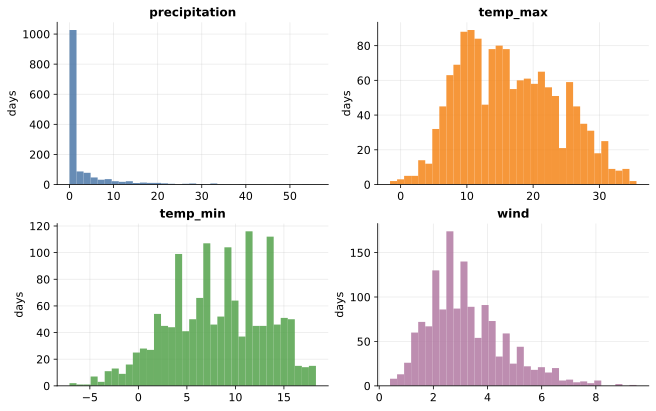

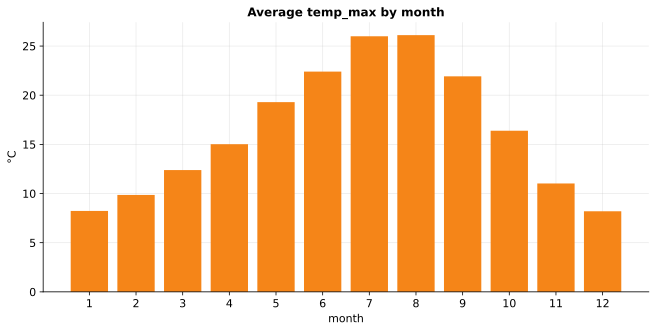

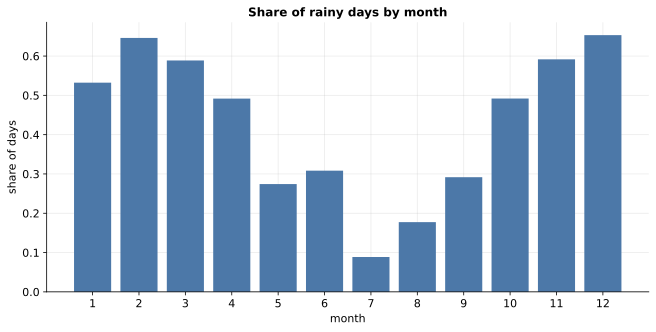

In [3]:
import matplotlib.pyplot as plt
from weather import load

d = load()
cols = ["precipitation", "temp_max", "temp_min", "wind"]
print(d[cols].describe().round(2), "\n")
print("missing values per column:", d[cols + ["weather"]].isna().sum().to_dict())
print("skewness:", d[cols].skew().round(2).to_dict(), "(precipitation is strongly right-skewed)")

fig, ax = plt.subplots(2, 2, figsize=(9, 5.6))
for a, c, colour in zip(ax.ravel(), cols, ["#4c78a8", "#f58518", "#54a24b", "#b279a2"]):
    a.hist(d[c], bins=35, color=colour, alpha=.85); a.set_title(c); a.set_ylabel("days")
plt.show()

monthly = d.groupby(d.date.dt.month).agg(temp_max=("temp_max", "mean"), rain_share=("rain", "mean"))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(monthly.index, monthly.temp_max, color="#f58518"); ax.set_title("Average temp_max by month"); ax.set_ylabel("°C")
ax.set_xlabel("month"); ax.set_xticks(range(1, 13)); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(monthly.index, monthly.rain_share, color="#4c78a8"); ax.set_title("Share of rainy days by month"); ax.set_ylabel("share of days")
ax.set_xlabel("month"); ax.set_xticks(range(1, 13)); plt.show()